In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import basedir
from training_configuration import PATHWAYS_2

data = "dream_cytof"

evaluations_dir = basedir / "eval_p38_v2"

df = pd.concat(
    pd.read_csv(evaluations_dir / model / data / "evaluate_all_figure2a.csv", index_col=0).assign(model=model)
    for model in PATHWAYS_2
)

In [2]:
val_df = df[df.dataset == "val"]
val_df.features.fillna("None", inplace=True)

In [3]:
val_df[val_df.ref == "DMM"].groupby(["model", "context"]).rmse.mean()

model                           context              
EGFR_MAPK__logobs               cytof_init               0.532069
                                cytof_init_plus_intr     0.541503
                                cytof_init_plus_lb       0.514392
                                cytof_init_plus_pEGFR    0.527051
                                cytof_init_plus_tEGFR    0.487413
                                multimodal               0.531156
EGFR_MAPK__logobs_fegfr_aggavg  cytof_init               0.530514
                                cytof_init_plus_intr     0.514848
                                cytof_init_plus_lb       0.517753
                                cytof_init_plus_pEGFR    0.533841
                                cytof_init_plus_tEGFR    0.477028
                                multimodal               0.537968
Name: rmse, dtype: float64

In [4]:
val_df[val_df.ref == "DMM"].groupby(["model", "context"]).rmse.median()

model                           context              
EGFR_MAPK__logobs               cytof_init               0.512143
                                cytof_init_plus_intr     0.564743
                                cytof_init_plus_lb       0.502423
                                cytof_init_plus_pEGFR    0.526149
                                cytof_init_plus_tEGFR    0.465969
                                multimodal               0.524941
EGFR_MAPK__logobs_fegfr_aggavg  cytof_init               0.513316
                                cytof_init_plus_intr     0.488420
                                cytof_init_plus_lb       0.492607
                                cytof_init_plus_pEGFR    0.508106
                                cytof_init_plus_tEGFR    0.468109
                                multimodal               0.507978
Name: rmse, dtype: float64

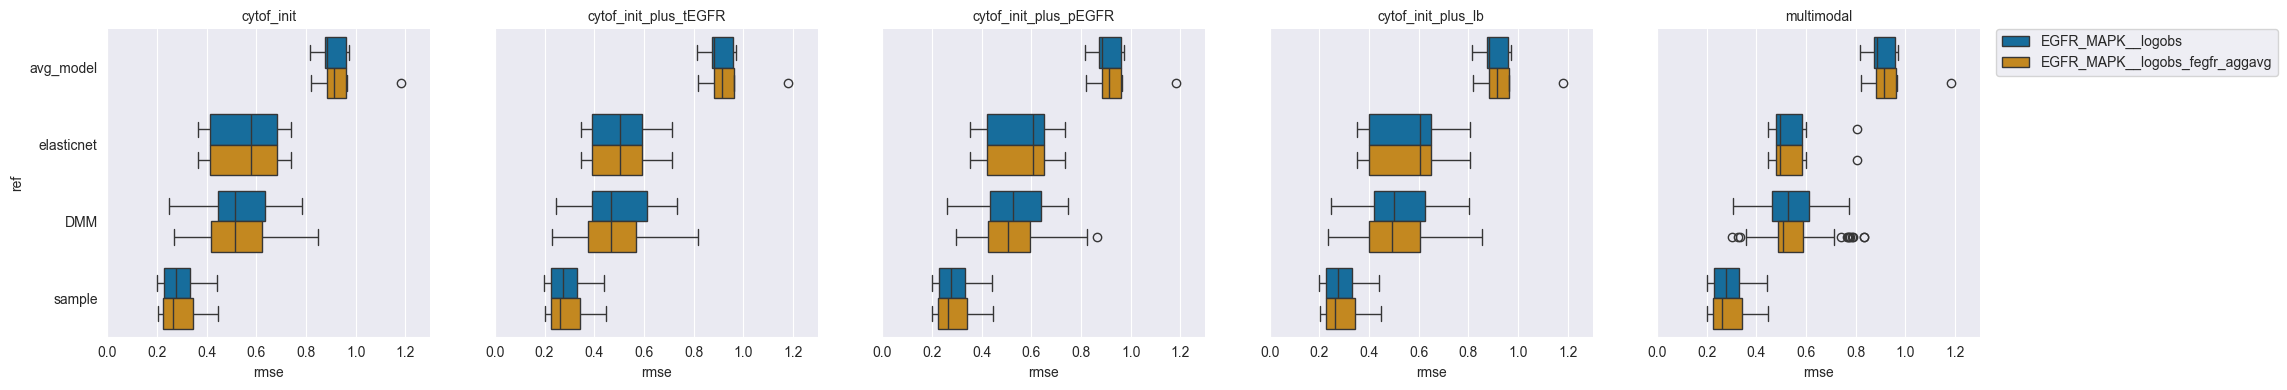

In [5]:
g = sns.FacetGrid(
    val_df[
        (val_df.ref.isin(["avg_model", "elasticnet", "DMM", "sample"])) &
        (val_df.context.isin(["cytof_init", "cytof_init_plus_tEGFR", "cytof_init_plus_pEGFR", "cytof_init_plus_lb", "multimodal"]))
    ],
    col="context",
    col_order=[
        "cytof_init", "cytof_init_plus_tEGFR",  "cytof_init_plus_pEGFR", "cytof_init_plus_lb", "multimodal"
    ],
    height=4,
    aspect=1
)

g.map_dataframe(
    sns.boxplot,
    y="ref",
    x="rmse",
    order=["avg_model", "elasticnet", "DMM", "sample",],
    hue="model",
    hue_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_fegfr_aggavg"],
    palette=sns.color_palette("colorblind"),
)
# Titles without prefixes
g.set_titles(row_template="{row_name}", col_template="{col_name}")

plt.xlim([0, 1.3])
plt.subplots_adjust(wspace=0.2)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

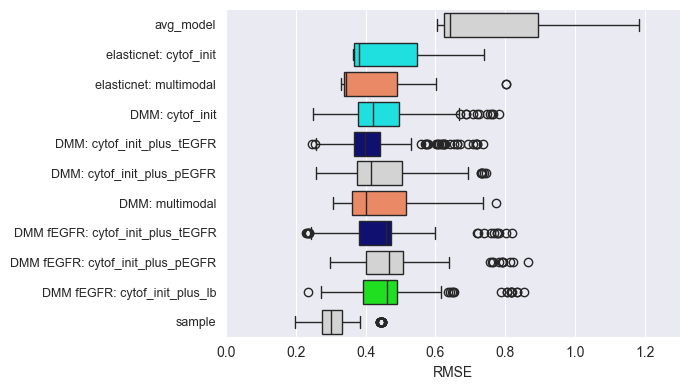

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- choose exactly the combos you want to display ---
want_elasticnet_contexts = ["cytof_init", "multimodal"]
want_dmm_logobs = ["cytof_init", "cytof_init_plus_tEGFR", "cytof_init_plus_pEGFR", "multimodal"]
want_dmm_fegfr = ["cytof_init_plus_tEGFR", "cytof_init_plus_pEGFR", "cytof_init_plus_lb"]

# Build a single display label per row
def mk_label(r):
    if r["ref"] == "avg_model":
        return "avg_model"
    if r["ref"] == "sample":
        return "sample"
    if r["ref"] == "elasticnet":
        if r["context"] in want_elasticnet_contexts:
            return f"elasticnet: {r['context']}"
        else:
            return None
    if r["ref"] == "DMM":
        if r["model"] == "EGFR_MAPK__logobs" and r["context"] in want_dmm_logobs:
            return f"DMM: {r['context']}"
        if r["model"] == "EGFR_MAPK__logobs_fegfr_aggavg" and r["context"] in want_dmm_fegfr:
            return f"DMM fEGFR: {r['context']}"
        return None
    # drop anything else
    return None

df["display_group"] = df.apply(mk_label, axis=1)
plot_df = df.dropna(subset=["display_group"]).copy()

# Order exactly as requested
order = [
    "avg_model",
    "elasticnet: cytof_init", "elasticnet: multimodal",
    "DMM: cytof_init",
    "DMM: cytof_init_plus_tEGFR",
    "DMM: cytof_init_plus_pEGFR",
    "DMM: multimodal",
    "DMM fEGFR: cytof_init_plus_tEGFR",
    "DMM fEGFR: cytof_init_plus_pEGFR",
    "DMM fEGFR: cytof_init_plus_lb",
    "sample",
]

# Map colors based on the context embedded in the label
ctx_color = {
    "cytof_init": "cyan",
    "cytof_init_plus_tEGFR": "navy",
    "cytof_init_plus_lb": "lime",
    "cytof_init_plus_intr": "red",
    "multimodal": "coral",
}
def label_color(lbl):
    # try to pull the context after the colon
    if ":" in lbl:
        ctx = lbl.split(": ", 1)[1]
        return ctx_color.get(ctx, "lightgray")
    # singleton categories without context
    return "lightgray"

palette = {lbl: label_color(lbl) for lbl in order}

# --- plot: no hue, so no empty subgroup space ---
plt.figure(figsize=(7, 4))
sns.boxplot(
    data=plot_df,
    y="display_group",
    x="rmse",
    order=order,
    palette=palette,
)
plt.yticks(fontsize=9)
plt.xlabel("RMSE")
plt.ylabel("")
plt.xlim(0, 1.3)
sns.despine()
plt.tight_layout()
# plt.savefig("RMSE_fig2_relevant_contexts.svg")

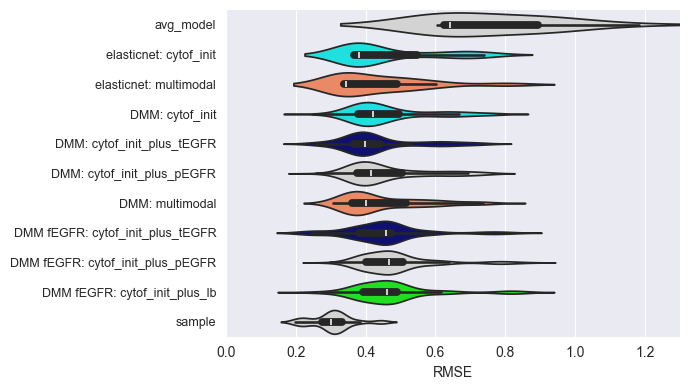

In [7]:
plt.figure(figsize=(7, 4))
sns.violinplot(
    data=plot_df,
    y="display_group",
    x="rmse",
    order=order,
    palette=palette,
)
plt.yticks(fontsize=9)
plt.xlabel("RMSE")
plt.ylabel("")
plt.xlim(0, 1.3)
sns.despine()
plt.tight_layout()

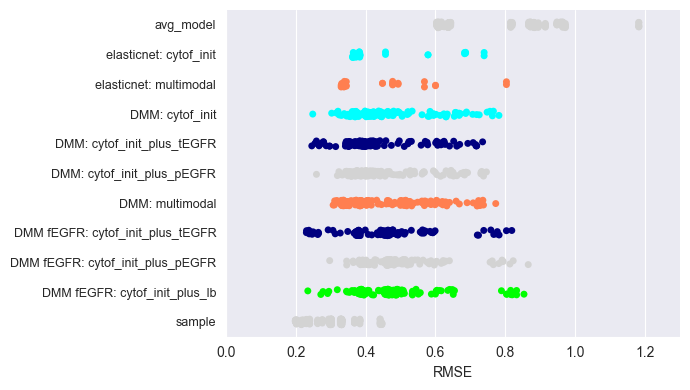

In [8]:
plt.figure(figsize=(7, 4))
sns.stripplot(
    data=plot_df,
    y="display_group",
    x="rmse",
    order=order,
    palette=palette,
)
plt.yticks(fontsize=9)
plt.xlabel("RMSE")
plt.ylabel("")
plt.xlim(0, 1.3)
sns.despine()
plt.tight_layout()

(0.0, 1.0)

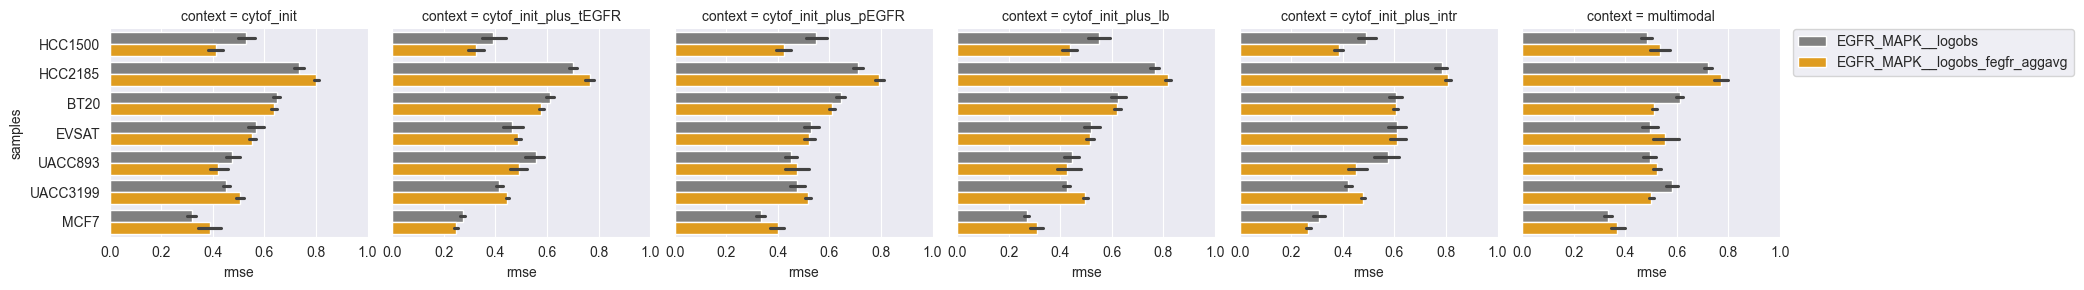

In [9]:
palette = {
    "EGFR_MAPK__logobs": "gray",
    "EGFR_MAPK__logobs_fegfr_aggavg": "orange",
}

g = sns.FacetGrid(
    val_df[val_df.ref == "DMM"],
    col="context",
    col_order=[
        "cytof_init",
        "cytof_init_plus_tEGFR",
        "cytof_init_plus_pEGFR",
        "cytof_init_plus_lb",
        "cytof_init_plus_intr",
        "multimodal"
    ]
)

g.map_dataframe(
    sns.barplot,
    x="rmse",
    y="samples",
    hue="model",
    hue_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_fegfr_aggavg"],
    palette=palette
)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.xlim([0, 1])

# Is there an improvement in going from `__logobs` with `cytof_init` to `__logobs_fegfr_aggavg` with `cytof_init_plus_tEGFR` or `cytof_init_plus_pEGFR`?

In [10]:
from scipy import stats

def kruskal_wallis_groups(df, target_metric, group_metric):
    for context in df['context'].unique():
        context_data = df[df['context'] == context]
        groups = [group[target_metric].values for _, group in context_data.groupby(group_metric)]
        stat, p_value = stats.kruskal(*groups)
        print(f"Context: {context} - Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}")

## Context-by-context, there is no significant improvement in going from `base` to `fegfr` -> need to look at more detailed comparisons

In [11]:
kruskal_wallis_groups(
    val_df[(val_df.ref.isin(["DMM"])) & (val_df.model.isin(["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_fegfr_aggavg"]))],
    "rmse",
    "model"
)

Context: multimodal - Kruskal-Wallis H-test: H-statistic=0.06, p-value=0.8058
Context: cytof_init - Kruskal-Wallis H-test: H-statistic=0.23, p-value=0.6347
Context: cytof_init_plus_intr - Kruskal-Wallis H-test: H-statistic=1.09, p-value=0.2955
Context: cytof_init_plus_tEGFR - Kruskal-Wallis H-test: H-statistic=0.25, p-value=0.6170
Context: cytof_init_plus_lb - Kruskal-Wallis H-test: H-statistic=0.01, p-value=0.9038
Context: cytof_init_plus_pEGFR - Kruskal-Wallis H-test: H-statistic=0.01, p-value=0.9435


## `cytof_init, base` -> `cytof_init_plus_tEGFR, base` - Yes (the former is significantly larger), both Wilcoxon and Kruskal

In [12]:
target_metric = "rmse"
groups = [
    val_df[(val_df.context == "cytof_init") & (val_df.model == "EGFR_MAPK__logobs") & (val_df.ref == "DMM")].sort_values(by=["samples", "job"]).rmse.values,
    val_df[(val_df.context == "cytof_init_plus_tEGFR") & (val_df.model == "EGFR_MAPK__logobs") & (val_df.ref == "DMM")].sort_values(by=["samples", "job"]).rmse.values,
]
stat, p = stats.wilcoxon(*groups, alternative="greater")
print(f"Wilcoxon signed-rank: W={stat}, p={p:.4g}")

Wilcoxon signed-rank: W=2034.0, p=1.811e-06


In [13]:
target_metric = "rmse"
groups = [
    val_df[(val_df.context == "cytof_init") & (val_df.model == "EGFR_MAPK__logobs") & (val_df.ref == "DMM")].sort_values(by=["samples", "job"]).rmse.values,
    val_df[(val_df.context == "cytof_init_plus_tEGFR") & (val_df.model == "EGFR_MAPK__logobs") & (val_df.ref == "DMM")].sort_values(by=["samples", "job"]).rmse.values,
]
stat, p_value = stats.kruskal(*groups)
print(f"Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}, significant? {p_value < 0.05}")

Kruskal-Wallis H-test: H-statistic=4.07, p-value=0.0437, significant? True


## `cytof_init, base` -> `cytof_init_plus_pEGFR, base` - No, confirms superiority of transcript vs protein levels for EGFR (degradation)

In [14]:
target_metric = "rmse"
groups = [
    val_df[(val_df.context == "cytof_init") & (val_df.model == "EGFR_MAPK__logobs") & (val_df.ref == "DMM")].sort_values(by=["samples", "job"]).rmse.values,
    val_df[(val_df.context == "cytof_init_plus_pEGFR") & (val_df.model == "EGFR_MAPK__logobs") & (val_df.ref == "DMM")].sort_values(by=["samples", "job"]).rmse.values,
]
stat, p = stats.wilcoxon(*groups, alternative="greater")
print(f"Wilcoxon signed-rank: W={stat}, p={p:.4g}")

Wilcoxon signed-rank: W=1373.0, p=0.2225


In [15]:
target_metric = "rmse"
groups = [
    val_df[(val_df.context == "cytof_init") & (val_df.model == "EGFR_MAPK__logobs") & (val_df.ref == "DMM")].sort_values(by=["samples", "job"]).rmse.values,
    val_df[(val_df.context == "cytof_init_plus_pEGFR") & (val_df.model == "EGFR_MAPK__logobs") & (val_df.ref == "DMM")].sort_values(by=["samples", "job"]).rmse.values,
]
stat, p_value = stats.kruskal(*groups)
print(f"Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}, significant? {p_value < 0.05}")

Kruskal-Wallis H-test: H-statistic=0.03, p-value=0.8610, significant? False


## `cytof_init, base` -> `cytof_init_plus_tEGFR, fegfr_aggavg` - Yes (the former is significantly larger; Wilcoxon score is larger than previous comparison)

In [16]:
target_metric = "rmse"
groups = [
    val_df[(val_df.context == "cytof_init") & (val_df.model == "EGFR_MAPK__logobs") & (val_df.ref == "DMM")].sort_values(by=["samples", "job"]).rmse.values,
    val_df[(val_df.context == "cytof_init_plus_tEGFR") & (val_df.model == "EGFR_MAPK__logobs_fegfr_aggavg") & (val_df.ref == "DMM")].sort_values(by=["samples", "job"]).rmse.values,
]
stat, p = stats.wilcoxon(*groups, alternative="greater")
print(f"Wilcoxon signed-rank: W={stat}, p={p:.4g}")

Wilcoxon signed-rank: W=2061.0, p=8.339e-07


In [17]:
target_metric = "rmse"
groups = [
    val_df[(val_df.context == "cytof_init") & (val_df.model == "EGFR_MAPK__logobs") & (val_df.ref == "DMM")].sort_values(by=["samples", "job"]).rmse.values,
    val_df[(val_df.context == "cytof_init_plus_tEGFR") & (val_df.model == "EGFR_MAPK__logobs_fegfr_aggavg") & (val_df.ref == "DMM")].sort_values(by=["samples", "job"]).rmse.values,
]
stat, p_value = stats.kruskal(*groups)
print(f"Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}, significant? {p_value < 0.05}")

Kruskal-Wallis H-test: H-statistic=5.22, p-value=0.0224, significant? True


## `cytof_init, base` -> `cytof_init_plus_pEGFR, fegfr_aggavg` - No (again)

In [18]:
target_metric = "rmse"
groups = [
    val_df[(val_df.context == "cytof_init") & (val_df.model == "EGFR_MAPK__logobs") & (val_df.ref == "DMM")].sort_values(by=["samples", "job"]).rmse.values,
    val_df[(val_df.context == "cytof_init_plus_pEGFR") & (val_df.model == "EGFR_MAPK__logobs_fegfr_aggavg") & (val_df.ref == "DMM")].sort_values(by=["samples", "job"]).rmse.values,
]
stat, p = stats.wilcoxon(*groups, alternative="greater")
print(f"Wilcoxon signed-rank: W={stat}, p={p:.4g}")

Wilcoxon signed-rank: W=1157.0, p=0.6916


In [19]:
target_metric = "rmse"
groups = [
    val_df[(val_df.context == "cytof_init") & (val_df.model == "EGFR_MAPK__logobs") & (val_df.ref == "DMM")].sort_values(by=["samples", "job"]).rmse.values,
    val_df[(val_df.context == "cytof_init_plus_pEGFR") & (val_df.model == "EGFR_MAPK__logobs_fegfr_aggavg") & (val_df.ref == "DMM")].sort_values(by=["samples", "job"]).rmse.values,
]
stat, p_value = stats.kruskal(*groups)
print(f"Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}, significant? {p_value < 0.05}")

Kruskal-Wallis H-test: H-statistic=0.07, p-value=0.7961, significant? False


## `cytof_init_plus_tEGFR, base` -> `cytof_init_plus_tEGFR, fegfr_aggavg` - No (neither greater nor two-sided Wilcoxon, tried both + neither Kruskal)

In [20]:
target_metric = "rmse"
groups = [
    val_df[(val_df.context == "cytof_init_plus_tEGFR") & (val_df.model == "EGFR_MAPK__logobs") & (val_df.ref == "DMM")].sort_values(by=["samples", "job"]).rmse.values,
    val_df[(val_df.context == "cytof_init_plus_tEGFR") & (val_df.model == "EGFR_MAPK__logobs_fegfr_aggavg") & (val_df.ref == "DMM")].sort_values(by=["samples", "job"]).rmse.values,
]
stat, p = stats.wilcoxon(*groups, alternative="greater")
print(f"Wilcoxon signed-rank: W={stat}, p={p:.4g}")

Wilcoxon signed-rank: W=1443.0, p=0.1203


In [21]:
target_metric = "rmse"
groups = [
    val_df[(val_df.context == "cytof_init_plus_tEGFR") & (val_df.model == "EGFR_MAPK__logobs") & (val_df.ref == "DMM")].sort_values(by=["samples", "job"]).rmse.values,
    val_df[(val_df.context == "cytof_init_plus_tEGFR") & (val_df.model == "EGFR_MAPK__logobs_fegfr_aggavg") & (val_df.ref == "DMM")].sort_values(by=["samples", "job"]).rmse.values,
]
stat, p = stats.wilcoxon(*groups, alternative="two-sided")
print(f"Wilcoxon signed-rank: W={stat}, p={p:.4g}")

Wilcoxon signed-rank: W=1042.0, p=0.2407


In [22]:
target_metric = "rmse"
groups = [
    val_df[(val_df.context == "cytof_init_plus_tEGFR") & (val_df.model == "EGFR_MAPK__logobs") & (val_df.ref == "DMM")].sort_values(by=["samples", "job"]).rmse.values,
    val_df[(val_df.context == "cytof_init_plus_tEGFR") & (val_df.model == "EGFR_MAPK__logobs_fegfr_aggavg") & (val_df.ref == "DMM")].sort_values(by=["samples", "job"]).rmse.values,
]
stat, p_value = stats.kruskal(*groups)
print(f"Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}, significant? {p_value < 0.05}")

Kruskal-Wallis H-test: H-statistic=0.25, p-value=0.6170, significant? False


# There is a significant gain in adding tEGFR to `cytof_init` - that information is clearly useful -> data-driven feature set augmentation. First level of mechanistic augmentation through fEGFR model is not successful though: no significant gain in using fEGFR vs base once we have added tEGFR feature.